### Import das Classes

In [92]:
%load_ext autoreload
%autoreload 2

import inspect
import matplotlib.pyplot as plt

from src.ProblemaP1 import ProblemaP1
from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP2 import ProblemaP2

print(inspect.getfile(ProblemaP1))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\fonso\Downloads\Classe_Problema_em_Redes\src\ProblemaP1.py


In [93]:
generator = ProblemaP1Generator(seed=42)
mu=1
patm=10
prob = generator.generate(num_nodes=100, edge_prob=0.15, mu=mu, patm=patm)

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>


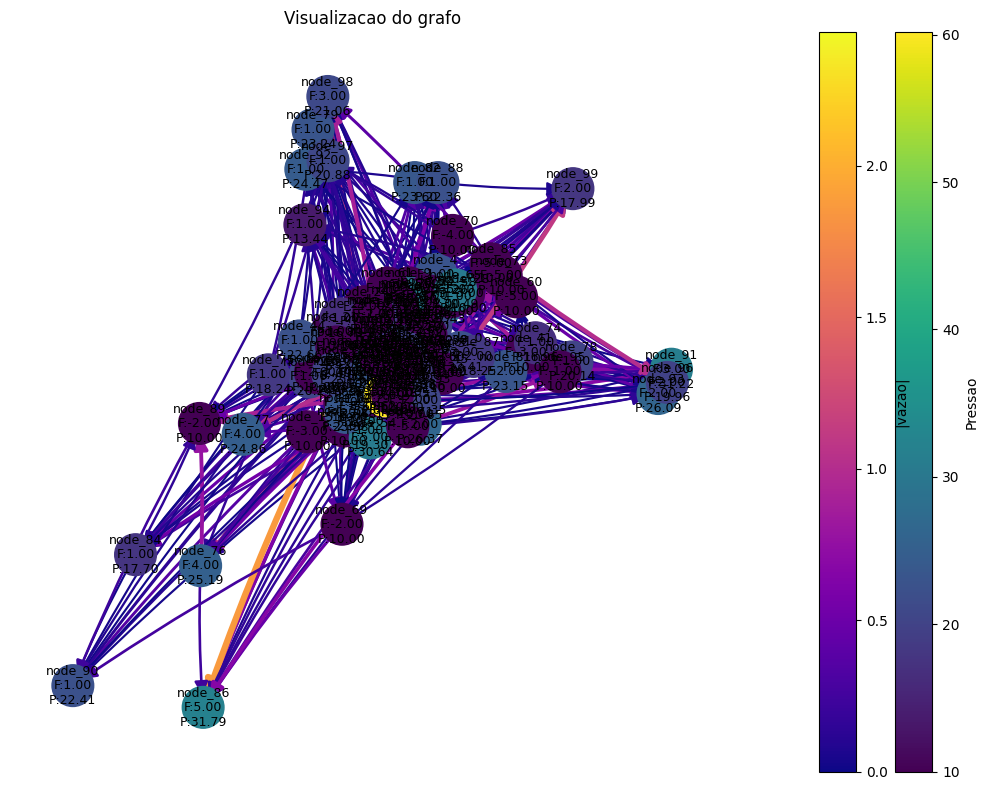

In [94]:
# Resolver problema determinístico
prob.setup()
prob.solve()

print(type(prob.A), type(prob.K), type(prob.M))
prob.plot(
    show_edge_labels=False,
    show_node_labels=True,
    layout='spring',
    node_value_attr='pressao',
    edge_value_attr='vazao'
)

In [95]:
isinstance(prob, ProblemaP1)

True

In [96]:
# Criar problema probabilístico
probabilistic_problem = ProblemaP2(
    p1_instance=prob, 
    r_prob=0.3,      # 30% de chance de obstrução
    alpha=2,         # resistência dobra
    P_max=65,         # pressão máxima = 1, 60 eh a pressao media quando nao temos obstrucao para 100 nos
    n_samples=1000,  # 1000 simulações
    seed=42
)

In [97]:
probabilistic_problem.setup()

In [98]:
# ==========================================
# TESTE 1: Análise completa com run()
# ==========================================
print("=" * 50)
print("Executando análise completa com 1000 simulações...")
probabilistic_problem.run()

print(f"\n📊 RESULTADOS:")
print(f"Probabilidade de falha: {probabilistic_problem.probability_of_failure():.4f} ({probabilistic_problem.probability_of_failure():.2%})")
print(f"Média da pressão máxima: {probabilistic_problem.summary()['mean_max_pressure']:.4f}")
print(f"Desvio padrão: {probabilistic_problem.summary()['std_max_pressure']:.4f}")

Executando análise completa com 1000 simulações...

📊 RESULTADOS:
Probabilidade de falha: 0.7650 (76.50%)
Média da pressão máxima: 69.7141
Desvio padrão: 6.0313


In [99]:
# ==========================================
# TESTE 2: Estimativa rápida
# ==========================================
print("\n" + "=" * 50)
print("Estimativa rápida com 100 simulações...")
pf, ic_low, ic_high = probabilistic_problem.estimate_pf(n_iter=100)
print(f"P_f = {pf:.4f} ({pf:.2%})")
print(f"IC 95%: [{ic_low:.4f}, {ic_high:.4f}]")


Estimativa rápida com 100 simulações...
P_f = 0.8000 (80.00%)
IC 95%: [0.7216, 0.8784]



Visualizando a rede...


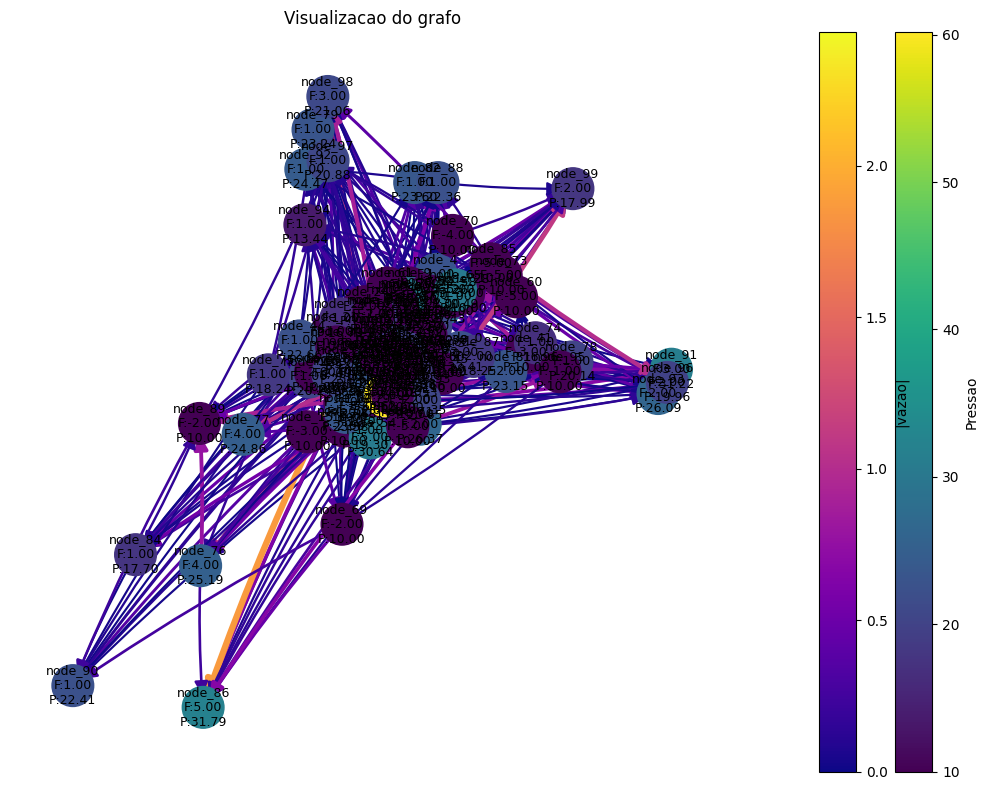


✅ Todos os testes concluidos!


In [100]:
# ==========================================
# TESTE 3: Visualizacao
# ==========================================
print("\n" + "=" * 50)
print("Visualizando a rede...")

probabilistic_problem.plot(
    show_edge_labels=False,
    show_node_labels=True,
    layout='spring',
    node_value_attr='pressao',
    edge_value_attr='vazao'
)

print("\n✅ Todos os testes concluidos!")

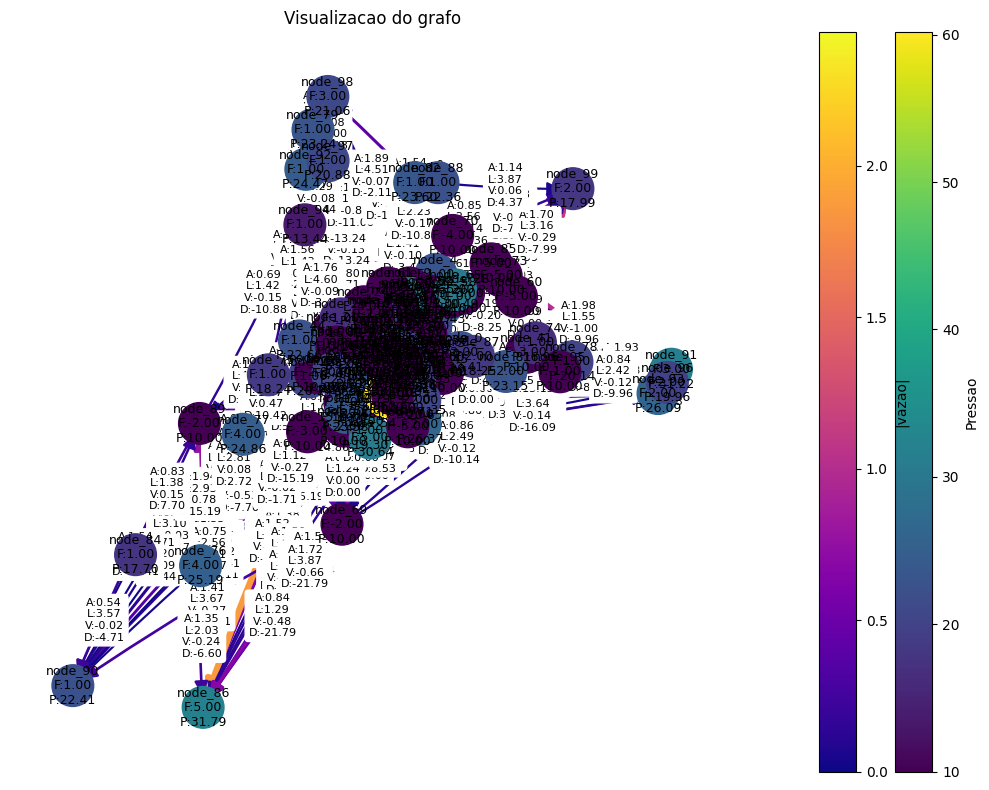

In [101]:
prob.setup()
prob.solve()

prob.plot(
    layout='spring',
    node_value_attr='pressao',
    edge_value_attr='vazao'
)

In [102]:
# Ver resultados
print(probabilistic_problem.summary())

{'n_samples': 1000, 'P_fail': 0.765, 'IC_95%': (0.7387207637194251, 0.791279236280575), 'mean_max_pressure': 69.71412451711726, 'std_max_pressure': 6.031336258889663, 'max_pressure_observed': 102.14107818501532, 'node_failure_prob': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.765, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}


In [103]:
# Estimar com mais precisão
pf, ci_lower, ci_upper = probabilistic_problem.estimate_pf(n_iter=500)
print(f"\nP_f = {pf:.4f} (IC 95%: [{ci_lower:.4f}, {ci_upper:.4f}])")


P_f = 0.7560 (IC 95%: [0.7184, 0.7936])


In [104]:
probabilistic_problem.estimate_pf(n_iter=100)

(0.76, 0.6762932446636111, 0.843706755336389)